In [ ]:
from google.colab import files
uploaded = files.upload()

Saving EduPro Online Platform (1).xlsx to EduPro Online Platform (1).xlsx


In [ ]:
import pandas as pd

xls = pd.ExcelFile('EduPro Online Platform (1).xlsx')
print(xls.sheet_names)

['Users', 'Teachers', 'Courses', 'Transactions']


In [ ]:
courses = pd.read_excel(xls, sheet_name='Courses')
teachers = pd.read_excel(xls, sheet_name='Teachers')
transactions = pd.read_excel(xls, sheet_name='Transactions')
users = pd.read_excel(xls, sheet_name='Users')

print("Courses shape:", courses.shape)
print("Teachers shape:", teachers.shape)
print("Transactions shape:", transactions.shape)
print("Users shape:", users.shape)

Courses shape: (60, 8)
Teachers shape: (60, 7)
Transactions shape: (10000, 7)
Users shape: (3000, 5)


In [ ]:
print("=== COURSES ===")
print(courses.head())
print(courses.isnull().sum())
print()
print("=== TRANSACTIONS ===")
print(transactions.head())
print(transactions.isnull().sum())

=== COURSES ===
  CourseID              CourseName CourseCategory CourseType   CourseLevel  \
0  CR00001           Python Basics    Programming       Paid      Beginner   
1  CR00002        Java Programming    Programming       Free  Intermediate   
2  CR00003       C++ for Beginners    Programming       Free      Beginner   
3  CR00004         Advanced Python    Programming       Free      Beginner   
4  CR00005  Full Stack Development    Programming       Free      Beginner   

   CoursePrice  CourseDuration  CourseRating  
0       472.28           11.00          4.74  
1         0.00           37.70          2.43  
2         0.00           19.53          3.85  
3         0.00           45.13          2.88  
4         0.00           28.68          1.28  
CourseID          0
CourseName        0
CourseCategory    0
CourseType        0
CourseLevel       0
CoursePrice       0
CourseDuration    0
CourseRating      0
dtype: int64

=== TRANSACTIONS ===
  TransactionID  UserID CourseID Trans

In [ ]:
# Step 1: Count enrollments and total revenue per course
course_perf = transactions.groupby('CourseID').agg(
    EnrollmentCount=('TransactionID', 'count'),
    CourseRevenue=('Amount', 'sum')
).reset_index()

# Step 2: Link transactions to teacher quality info
trans_teachers = transactions.merge(teachers, on='TeacherID', how='left')

teacher_agg = trans_teachers.groupby('CourseID').agg(
    AvgTeacherRating=('TeacherRating', 'mean'),
    AvgTeacherExperience=('YearsOfExperience', 'mean')
).reset_index()

# Step 3: Combine everything into one course-level table
course_master = courses.merge(course_perf, on='CourseID', how='left') \
                        .merge(teacher_agg, on='CourseID', how='left')

# Step 4: A useful derived column
course_master['RevenuePerEnrollment'] = course_master['CourseRevenue'] / course_master['EnrollmentCount']

print(course_master.shape)
course_master.head(10)

(60, 13)


,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating,EnrollmentCount,CourseRevenue,AvgTeacherRating,AvgTeacherExperience,RevenuePerEnrollment
0,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.00,4.74,164,77453.92,4.191646,16.682927,472.28
1,CR00002,Java Programming,Programming,Free,Intermediate,0.00,37.70,2.43,149,0.00,4.211409,17.013423,0.00
2,CR00003,C++ for Beginners,Programming,Free,Beginner,0.00,19.53,3.85,173,0.00,4.079017,16.589595,0.00
3,CR00004,Advanced Python,Programming,Free,Beginner,0.00,45.13,2.88,154,0.00,4.097987,15.896104,0.00
4,CR00005,Full Stack Development,Programming,Free,Beginner,0.00,28.68,1.28,166,0.00,4.058554,15.795181,0.00
5,CR00006,Graphic Design Basics,Design,Paid,Advanced,276.37,48.84,2.72,156,43113.72,4.133462,16.750000,276.37
6,CR00007,UI/UX Design,Design,Free,Advanced,0.00,48.68,2.61,178,0.00,3.932584,16.022472,0.00
7,CR00008,Photoshop Mastery,Design,Free,Advanced,0.00,2.87,1.52,158,0.00,3.999114,16.329114,0.00
8,CR00009,Web Design Fundamentals,Design,Free,Beginner,0.00,48.19,4.51,155,0.00,3.956258,15.387097,0.00
9,CR00010,3D Modeling,Design,Free,Advanced,0.00,15.29,4.45,180,0.00,3.997056,16.050000,0.00


In [ ]:
# Price bands
course_master['PriceBand'] = pd.cut(course_master['CoursePrice'],
    bins=[-1, 0, 100, 250, 1000],
    labels=['Free', 'Low', 'Medium', 'High'])

# Duration buckets
course_master['DurationBucket'] = pd.cut(course_master['CourseDuration'],
    bins=[0, 10, 25, 40, 100],
    labels=['Short', 'Medium', 'Long', 'VeryLong'])

# Rating tier
course_master['RatingTier'] = pd.cut(course_master['CourseRating'],
    bins=[0, 2, 3.5, 5],
    labels=['Low', 'Mid', 'High'])

# Teacher experience bucket
course_master['ExperienceBucket'] = pd.cut(course_master['AvgTeacherExperience'],
    bins=[0, 5, 10, 30],
    labels=['Junior', 'Mid', 'Senior'])

print(course_master[['CourseName','PriceBand','DurationBucket','RatingTier','ExperienceBucket']].head(10))

                CourseName PriceBand DurationBucket RatingTier  \
0            Python Basics      High         Medium       High   
1         Java Programming      Free           Long        Mid   
2        C++ for Beginners      Free         Medium       High   
3          Advanced Python      Free       VeryLong        Mid   
4   Full Stack Development      Free           Long        Low   
5    Graphic Design Basics      High       VeryLong        Mid   
6             UI/UX Design      Free       VeryLong        Mid   
7        Photoshop Mastery      Free          Short        Low   
8  Web Design Fundamentals      Free       VeryLong       High   
9              3D Modeling      Free         Medium       High   

  ExperienceBucket  
0           Senior  
1           Senior  
2           Senior  
3           Senior  
4           Senior  
5           Senior  
6           Senior  
7           Senior  
8           Senior  
9           Senior  


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Select the features we'll use to predict
features_df = course_master[['CourseCategory','CourseType','CourseLevel','CoursePrice',
                               'CourseDuration','CourseRating','AvgTeacherRating',
                               'AvgTeacherExperience','PriceBand','DurationBucket',
                               'RatingTier','ExperienceBucket']].copy()

# One-hot encode text categories into 0/1 columns
features_encoded = pd.get_dummies(features_df, drop_first=True)

print(features_encoded.shape)
features_encoded.head()

(60, 29)


,CoursePrice,CourseDuration,CourseRating,AvgTeacherRating,AvgTeacherExperience,CourseCategory_Business,CourseCategory_Cybersecurity,CourseCategory_Data Science,CourseCategory_Design,CourseCategory_Digital Marketing,...,PriceBand_Low,PriceBand_Medium,PriceBand_High,DurationBucket_Medium,DurationBucket_Long,DurationBucket_VeryLong,RatingTier_Mid,RatingTier_High,ExperienceBucket_Mid,ExperienceBucket_Senior
0,472.28,11.00,4.74,4.191646,16.682927,False,False,False,False,False,...,False,False,True,True,False,False,False,True,False,True
1,0.00,37.70,2.43,4.211409,17.013423,False,False,False,False,False,...,False,False,False,False,True,False,True,False,False,True
2,0.00,19.53,3.85,4.079017,16.589595,False,False,False,False,False,...,False,False,False,True,False,False,False,True,False,True
3,0.00,45.13,2.88,4.097987,15.896104,False,False,False,False,False,...,False,False,False,False,False,True,True,False,False,True
4,0.00,28.68,1.28,4.058554,15.795181,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True


In [ ]:
from sklearn.model_selection import train_test_split

X = features_encoded
y = course_master['EnrollmentCount']  # our main target for now

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape, " Test size:", X_test.shape)

Train size: (48, 29)  Test size: (12, 29)


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

lr = LinearRegression().fit(X_train, y_train)
ridge = Ridge().fit(X_train, y_train)
rf = RandomForestRegressor(n_estimators=200, random_state=42).fit(X_train, y_train)

print("Models trained successfully!")

Models trained successfully!


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

lr = LinearRegression().fit(X_train, y_train)
ridge = Ridge().fit(X_train, y_train)
rf = RandomForestRegressor(n_estimators=200, random_state=42).fit(X_train, y_train)

print("Models trained successfully!")

Models trained successfully!


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

for name, model in [('Linear Regression', lr), ('Ridge', ridge), ('Random Forest', rf)]:
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"{name}: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.3f}")

Linear Regression: MAE=11.23, RMSE=14.01, R2=-0.077
Ridge: MAE=8.52, RMSE=10.80, R2=0.360
Random Forest: MAE=10.25, RMSE=12.40, R2=0.157


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# New target: Course Revenue
y_rev = course_master['CourseRevenue']

X_train, X_test, y_train, y_test = train_test_split(X, y_rev, test_size=0.2, random_state=42)

lr_rev = LinearRegression().fit(X_train, y_train)
ridge_rev = Ridge().fit(X_train, y_train)
rf_rev = RandomForestRegressor(n_estimators=200, random_state=42).fit(X_train, y_train)
gb_rev = GradientBoostingRegressor(random_state=42).fit(X_train, y_train)

print("=== Predicting Course Revenue ===")
for name, model in [('Linear Regression', lr_rev), ('Ridge', ridge_rev),
                     ('Random Forest', rf_rev), ('Gradient Boosting', gb_rev)]:
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"{name}: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.3f}")

=== Predicting Course Revenue ===
Linear Regression: MAE=3341.43, RMSE=4043.43, R2=0.979
Ridge: MAE=3131.80, RMSE=3837.83, R2=0.981
Random Forest: MAE=3350.62, RMSE=5423.19, R2=0.962
Gradient Boosting: MAE=3152.98, RMSE=4552.57, R2=0.973


In [ ]:
# Category Revenue is one value per category, not per course - so we aggregate differently
category_df = course_master.groupby('CourseCategory').agg(
    CategoryRevenue=('CourseRevenue', 'sum'),
    AvgPrice=('CoursePrice', 'mean'),
    AvgDuration=('CourseDuration', 'mean'),
    AvgRating=('CourseRating', 'mean'),
    AvgTeacherRating=('AvgTeacherRating', 'mean'),
    NumCourses=('CourseID', 'count')
).reset_index()

print(category_df)

             CourseCategory  CategoryRevenue  AvgPrice  AvgDuration  \
0   Artificial Intelligence        202750.67   248.820       17.906   
1                  Business        181527.58   219.798       24.046   
2             Cybersecurity         59139.00    78.852       36.308   
3              Data Science         77052.32    83.450       27.992   
4                    Design         43113.72    55.274       32.774   
5         Digital Marketing         56261.32    77.946       17.796   
6                   Finance         28106.20    34.580       28.690   
7          Machine Learning           133.38     0.156       31.356   
8                 Marketing             0.00     0.000       30.348   
9               Programming         77453.92    94.456       28.408   
10       Project Management        169103.21   203.462       16.474   
11          Web Development         16682.15    19.042       39.492   

    AvgRating  AvgTeacherRating  NumCourses  
0       3.036          4.00948

In [ ]:
X_cat = category_df[['AvgPrice','AvgDuration','AvgRating','AvgTeacherRating','NumCourses']]
y_cat = category_df['CategoryRevenue']

# With only 12 rows, we skip train/test split and just check how well it fits
lr_cat = LinearRegression().fit(X_cat, y_cat)
preds_cat = lr_cat.predict(X_cat)
print("Category Revenue R2 (in-sample, small data caveat applies):", r2_score(y_cat, preds_cat))

Category Revenue R2 (in-sample, small data caveat applies): 0.9986857251268237


CourseRating                        0.240106
CourseDuration                      0.168463
CourseCategory_Data Science         0.138303
AvgTeacherExperience                0.096132
AvgTeacherRating                    0.075794
CourseLevel_Intermediate            0.040643
PriceBand_Medium                    0.034102
CourseCategory_Digital Marketing    0.031111
CourseCategory_Marketing            0.029743
CourseLevel_Beginner                0.029449
dtype: float64


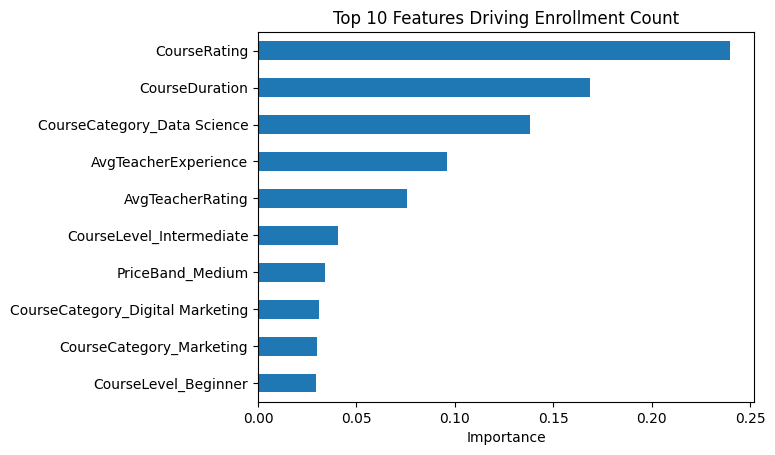

In [ ]:
import matplotlib.pyplot as plt

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances.head(10))

importances.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 10 Features Driving Enrollment Count')
plt.xlabel('Importance')
plt.show()

In [ ]:
import joblib

joblib.dump(rf, 'model_enrollment.pkl')
joblib.dump(rf_rev, 'model_revenue.pkl')
joblib.dump(list(X.columns), 'feature_columns.pkl')  # so we know the exact column order later

print("Models saved!")

Models saved!


In [ ]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(10).to_csv('feature_importance.csv')

In [ ]:
category_summary = course_master.groupby('CourseCategory').agg(
    TotalEnrollment=('EnrollmentCount', 'sum'),
    TotalRevenue=('CourseRevenue', 'sum'),
    AvgPrice=('CoursePrice', 'mean'),
    AvgRating=('CourseRating', 'mean'),
    NumCourses=('CourseID', 'count')
).reset_index().sort_values('TotalEnrollment', ascending=False)

print(category_summary)
category_summary.to_csv('category_summary.csv', index=False)

             CourseCategory  TotalEnrollment  TotalRevenue  AvgPrice  \
3              Data Science              916      77052.32    83.450   
6                   Finance              864      28106.20    34.580   
11          Web Development              844      16682.15    19.042   
1                  Business              833     181527.58   219.798   
10       Project Management              829     169103.21   203.462   
0   Artificial Intelligence              829     202750.67   248.820   
4                    Design              827      43113.72    55.274   
2             Cybersecurity              819      59139.00    78.852   
7          Machine Learning              819        133.38     0.156   
5         Digital Marketing              808      56261.32    77.946   
9               Programming              806      77453.92    94.456   
8                 Marketing              806          0.00     0.000   

    AvgRating  NumCourses  
3       3.316           5  
6      